# Analyse exploratoire des données — Dataset Titanic

> **Objectif :** Analyser les données du Titanic afin d'identifier les facteurs liés à la survie des passagers, en vue de construire un modèle de classification performant.  
**Auteurs :** Van Zieleghem Victor, Dai Pra Adrien.
---

## Table des matières

**Analyse classique**
1. [Importation des librairies](#section-1)
2. [Chargement et aperçu des données](#section-2)
3. [Statistiques descriptives](#section-3)
4. [Analyse des valeurs manquantes](#section-4)
5. [Analyse de la variable cible : `survived`](#section-5)
6. [Distribution du port d'embarquement](#section-6)
7. [Identification des types de variables](#section-7)
8. [Distribution des variables continues](#section-8)
9. [Matrice de corrélation](#section-9)
10. [Détection des valeurs aberrantes (outliers)](#section-10)
11. [Taux de survie selon le titre social](#section-11)
12. [Taux de survie selon la classe de billet](#section-12)

**Réflexion originale**

13. [Survie selon le sexe](#section-13)
14. [Feature Engineering : nouvelles variables](#section-14)
15. [Synthèse des facteurs de survie](#section-15)

---
## 1. Importation des librairies <a id='section-1'></a>

On commence par importer les librairies nécessaires à l'analyse :
- **pandas** et **numpy** : manipulation et traitement des données tabulaires ;
- **matplotlib** et **seaborn** : création de graphiques et visualisations ;
- **scipy.stats** : transformations statistiques, notamment la transformation de Yeo-Johnson qui sera utile pour normaliser les distributions asymétriques.

In [1]:
import pandas as pd
import numpy as np

# for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# for the yeo-johnson transformation
import scipy.stats as stats

pd.pandas.set_option('display.max_columns', None)

Les librairies sont importées. Aucune erreur à ce stade indique que l'environnement est correctement configuré.

---
## 2. Chargement et aperçu des données <a id='section-2'></a>

On charge le fichier CSV depuis le répertoire courant (le fichier doit se trouver dans le même dossier que ce notebook). On affiche ensuite les dimensions du dataset ainsi qu'un aperçu des premières lignes pour avoir une première impression des données disponibles.

In [2]:
df_data = pd.read_csv('Titanic Dataset.csv')

# rows and columns of the data
print(df_data.shape)

# visualise the data
df_data

(1309, 11)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C


Le dataset contient **1309 passagers** (lignes) et **11 variables** (colonnes). On y trouve des informations variées : identité, classe sociale, sexe, âge, tarif payé, port d'embarquement, cabine, et bien sûr la variable cible `survived`.

---
## 3. Statistiques descriptives <a id='section-3'></a>

La méthode `info()` donne un aperçu des types de données et du nombre de valeurs non-nulles par colonne. La méthode `describe()` fournit les statistiques de base (moyenne, écart-type, quartiles) pour toutes les variables numériques. Ces deux fonctions permettent d'identifier rapidement les premières anomalies.

In [3]:
df_data.info()
df_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   ticket    1309 non-null   object 
 8   fare      1308 non-null   float64
 9   cabin     295 non-null    object 
 10  embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


On observe plusieurs points importants :
- Certaines colonnes comme `age`, `cabin` ou `embarked` ont moins de 1309 valeurs non-nulles, ce qui signale des **données manquantes** à traiter.
- Le tarif (`fare`) présente un maximum très élevé par rapport à sa moyenne, ce qui laisse supposer des **valeurs aberrantes**.
- La variable `survived` est de type entier (0 pour mort ou 1 pour vivant) : il s'agit d'une **classification binaire**.

---
## 4. Analyse des valeurs manquantes <a id='section-4'></a>

Les valeurs manquantes peuvent fausser l'analyse et les modèles de Machine Learning. On identifie ici quelles colonnes en contiennent et dans quelle proportion, afin de décider comment les traiter (suppression, imputation, etc.).

In [4]:
def display_missing_values(df):
    """Identifie et affiche les variables avec valeurs manquantes et leur pourcentage."""
    l_vars_with_na = [var for var in df.columns if df[var].isnull().sum() > 0]
    print("Variables avec valeurs manquantes :", l_vars_with_na)
    print(df[l_vars_with_na].isnull().mean().sort_values(ascending=False))

display_missing_values(df_data)

Variables avec valeurs manquantes : ['age', 'fare', 'cabin', 'embarked']
cabin       0.774637
age         0.200917
embarked    0.001528
fare        0.000764
dtype: float64


Trois variables présentent des valeurs manquantes :
- **`cabin`** : plus de 77% de valeurs manquantes — cette variable sera difficile à utiliser telle quelle. On pourra la transformer en indicateur binaire (cabine connue ou non).
- **`age`** : environ 20% de valeurs manquantes — une imputation (par exemple par la médiane selon le titre social) sera nécessaire.
- **`embarked`** : moins de 1% de valeurs manquantes — on peut remplacer par la valeur la plus fréquente (mode).

---
## 5. Analyse de la variable cible : `survived` <a id='section-5'></a>

Avant toute modélisation, il est essentiel de comprendre la distribution de la variable cible. Un fort déséquilibre entre les classes (beaucoup plus de 0 que de 1, ou inversement) peut biaiser les résultats d'un modèle et nécessite des ajustements.

survived
0    809
1    500
Name: count, dtype: int64


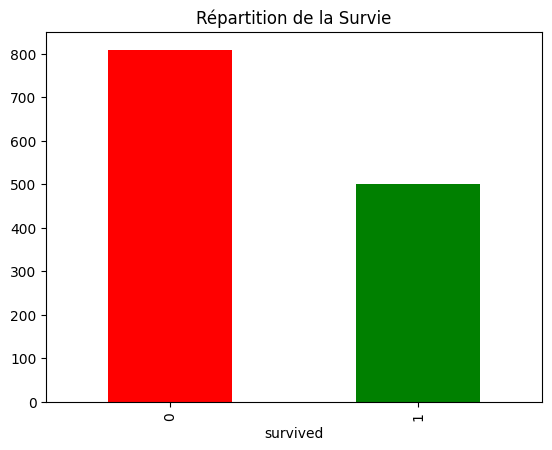

In [5]:
# Analyse de la survie (0 = Non, 1 = Oui)
print(df_data['survived'].value_counts())

# Visualisation rapide
df_data['survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title("Répartition de la Survie")
plt.show()

Le dataset est **légèrement déséquilibré** : environ 62% de non-survivants contre 38% de survivants. Ce déséquilibre est modéré — il sera néanmoins important d'en tenir compte lors de la phase de modélisation (préférer le F1-score ou l'AUC plutôt que la simple accuracy comme métrique d'évaluation).

---
## 6. Distribution du port d'embarquement <a id='section-6'></a>

La variable `embarked` indique le port d'embarquement du passager. On souhaite connaître sa distribution pour anticiper un éventuel encodage et vérifier si ce facteur pourrait être lié à la survie (via la classe sociale, par exemple).

In [6]:
# Compter les occurrences de chaque classe
churn_counts = df_data["embarked"].value_counts()

# Afficher les résultats
print(churn_counts)

embarked
S    914
C    270
Q    123
Name: count, dtype: int64


La majorité des passagers ont embarqué à **Southampton (S)**, suivi de **Cherbourg (C)** et **Queenstown (Q)**. Cette variable pourrait être liée indirectement à la classe sociale des passagers selon leur port d'origine, et donc à la survie.

---
## 7. Identification des types de variables <a id='section-7'></a>

Pour choisir les bonnes méthodes d'analyse et de prétraitement, il est essentiel de distinguer les types de variables :
- **Variables discrètes** : numériques avec un nombre limité de valeurs entières ;
- **Variables continues** : numériques à valeurs réelles (distribution à analyser) ;
- **Variables catégorielles** : textuelles, à encoder avant modélisation.

In [7]:
def identify_variable_types(df, discrete_threshold=20):
    """Identifie et retourne les variables numériques, discrètes, catégorielles et continues."""
    # 1. Variables numériques
    l_num_vars = [var for var in df.columns if df[var].dtype != 'O']

    # 2. Variables discrètes
    l_discrete_vars = [var for var in l_num_vars
                       if len(df[var].unique()) < discrete_threshold ]

    print('Nombre de variables discrètes : ', len(l_discrete_vars))
    print(l_discrete_vars)

    # 3. Variables catégorielles
    l_cat_vars = [var for var in df.columns if df[var].dtype == 'O']

    print("Nombre de variables catégorielles :", len(l_cat_vars))
    print(l_cat_vars)

    # 4. Variables continues
    l_cont_vars = [var for var in l_num_vars if var not in l_discrete_vars]
    print("Variables continues :", l_cont_vars)

    return l_num_vars, l_discrete_vars, l_cat_vars, l_cont_vars


l_num_vars, l_discrete_vars, l_cat_vars, l_cont_vars = identify_variable_types(df_data)

Nombre de variables discrètes :  4
['pclass', 'survived', 'sibsp', 'parch']
Nombre de variables catégorielles : 5
['name', 'sex', 'ticket', 'cabin', 'embarked']
Variables continues : ['age', 'fare']


On obtient trois types distincts :
- Les **variables discrètes** (`pclass`, `sibsp`, `parch`,`survived`) prennent un petit nombre de valeurs entières.
- Les **variables continues** (`age`, `fare`) nécessiteront une analyse de distribution et potentiellement une transformation.
- Les **variables catégorielles** (`sex`, `embarked`, `cabin`, `name`, `ticket`) devront être encodées avant d'être intégrées à un modèle.
- **`survived`** est une variable binaire, mise, à part, car c'est le caractère etudié de ce travail.

---
## 8. Distribution des variables continues <a id='section-8'></a>

Les histogrammes permettent de visualiser la forme de la distribution des variables continues. On cherche notamment à identifier des **asymétries** (skewness) qui pourraient nécessiter une transformation (logarithmique ou Yeo-Johnson) avant la modélisation.

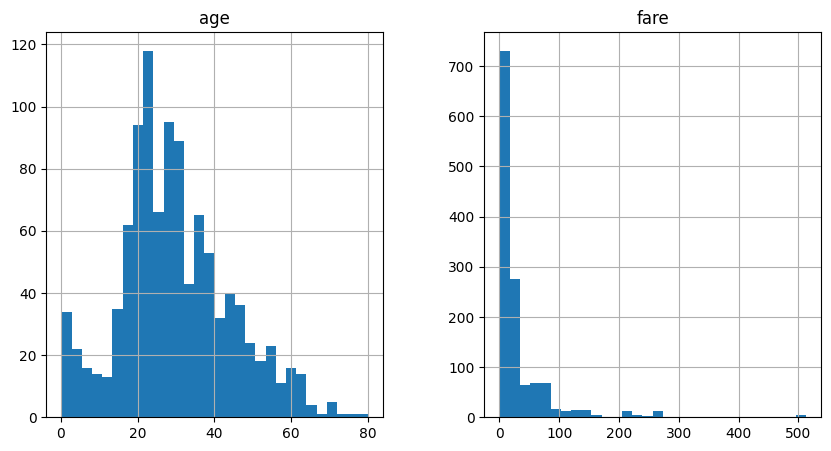

In [8]:
df_data[l_cont_vars].hist(bins=30, figsize=(10, 5))
plt.show()

- **`age`** : la distribution est globalement symétrique, avec une légère asymétrie et une concentration entre 20 et 40 ans.
- **`fare`** : la distribution est fortement asymétrique, la plupart des passagers ont payé un tarif modeste, mais quelques valeurs extrêmes tirent la moyenne vers le haut. Une transformation (ex. Yeo-Johnson) sera probablement nécessaire.

---
## 9. Matrice de corrélation <a id='section-9'></a>

La matrice de corrélation permet de mesurer les relations linéaires entre les variables numériques. Elle aide à identifier les variables les plus corrélées avec la cible (`survived`), et à détecter la **multicolinéarité** entre variables explicatives, qui peut nuire à certains modèles.

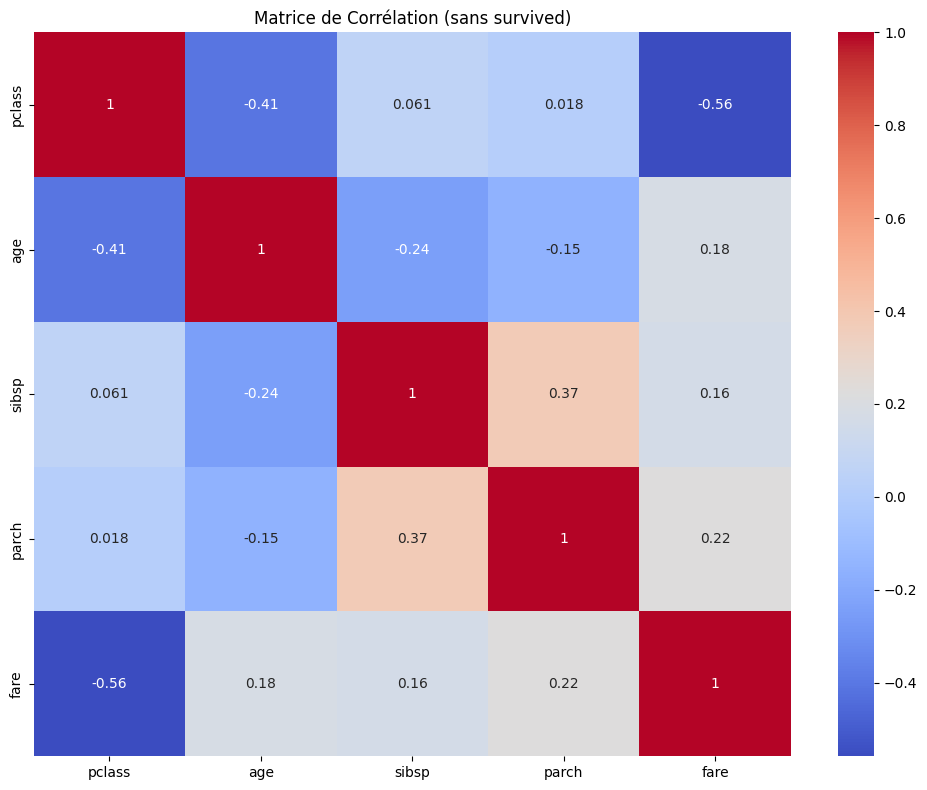

In [9]:
# matrice de corrélation SANS la variable cible 'survived'
num_vars_no_target = [v for v in l_num_vars if v != 'survived']

plt.figure(figsize=(10, 8))
sns.heatmap(df_data[num_vars_no_target].corr(), annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation (sans survived)')
plt.tight_layout()
plt.show()

La matrice montre les corrélations entre les variables explicatives numériques (sans la cible `survived`) :
- **`fare`** et **`pclass`** sont fortement corrélées entre elles (multicolinéarité) — les billets coûteux correspondent aux meilleures classes.
- **`sibsp`** et **`parch`** sont légèrement corrélées — elles mesurent toutes deux la taille de la famille.
- Cette multicolinéarité devra être prise en compte lors de la modélisation (risque de redondance entre certaines variables).

---
## 10. Détection des valeurs aberrantes (outliers) <a id='section-10'></a>

Les valeurs aberrantes peuvent fortement influencer les résultats d'un modèle. On utilise un **boxplot** pour visualiser leur présence sur la variable `fare`, dont la distribution asymétrique laissait supposer des valeurs extrêmes.

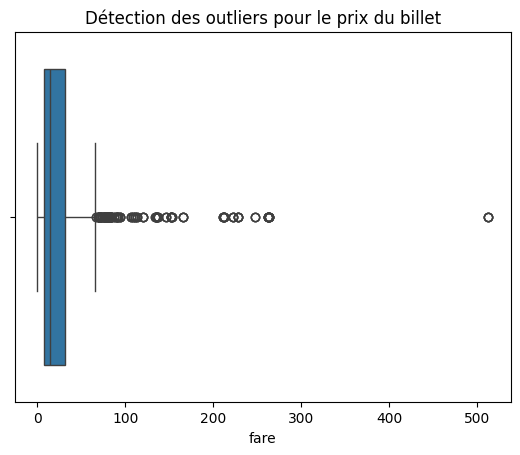

In [10]:
# Exemple pour le prix du billet (Fare)
sns.boxplot(x=df_data['fare'])
plt.title("Détection des outliers pour le prix du billet")
plt.show()

Le boxplot confirme la présence de **nombreuses valeurs aberrantes** pour le tarif : plusieurs passagers ont payé des prix très largement supérieurs à la médiane. Ces outliers devront être traités (transformation, capping, etc.) avant la phase de modélisation pour éviter qu'ils ne dominent l'entraînement du modèle.

---
## 11. Taux de survie selon le titre social <a id='section-11'></a>

Le titre social (Mr, Mrs, Miss, Master…) peut être extrait directement depuis la colonne `name`. Il constitue une variable proxy intéressante, car il reflète à la fois le sexe, l'âge approximatif et le statut social du passager — tous des facteurs potentiellement liés à la survie.

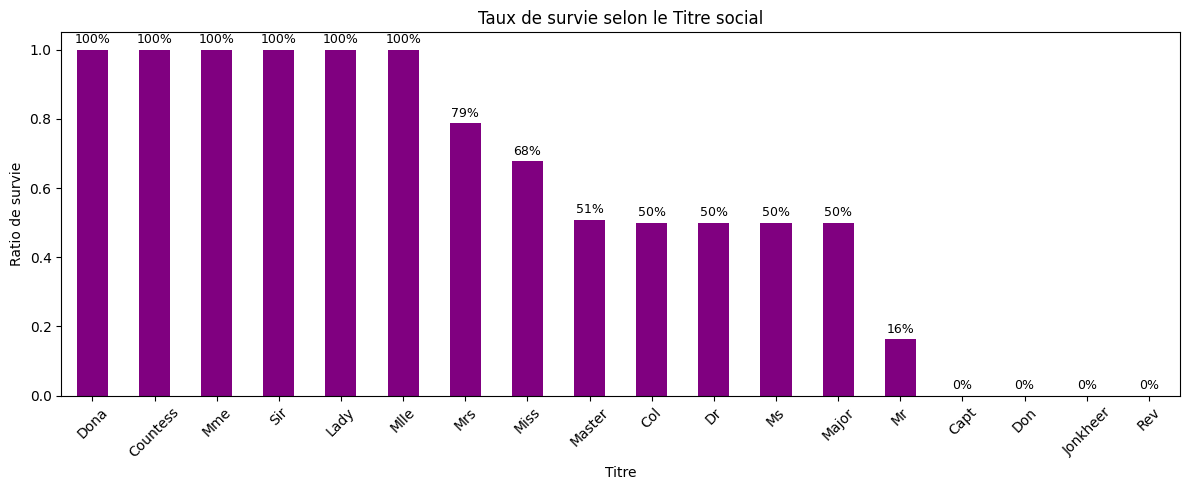

In [11]:
df_data['Title'] = df_data['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# liste des titres valides (on retire les faux noms comme 'y' issu de 'Oliva y Ocana')
valid_titles = ['Mr', 'Mrs', 'Miss', 'Master', 'Dr', 'Rev', 'Col', 'Major',
                'Mlle', 'Ms', 'Mme', 'Lady', 'Capt', 'Sir', 'Don', 'Dona',
                'Jonkheer', 'Countess']

df_titles = df_data[df_data['Title'].isin(valid_titles)].copy()

table_titles = pd.crosstab(df_titles['Title'], df_titles['survived'], normalize='index')
ax = table_titles[1].sort_values(ascending=False).plot(kind='bar', figsize=(12, 5), color='purple')

# affichage du pourcentage sur chaque barre
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)

plt.title('Taux de survie selon le Titre social')
plt.ylabel('Ratio de survie')
plt.xlabel('Titre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Les titres féminins (**Mrs**, **Miss**) affichent un taux de survie nettement plus élevé, ce qui confirme la règle historique "femmes et enfants d'abord". Le titre **Master** (jeunes garçons) montre également un bon taux de survie. À l'inverse, **Mr** présente le taux le plus faible. Cette variable sera très utile en modélisation, et pourra être simplifiée en regroupant les titres rares (Countess, Jonkheer, etc.) dans une catégorie "Rare".

---
## 12. Taux de survie selon la classe de billet <a id='section-12'></a>

La classe de billet (`pclass`) est une variable ordinale (1 = 1ère classe, 2 = 2ème, 3 = 3ème). On compare ici les taux de survie entre les classes pour quantifier l'impact du statut économique sur les chances de survie.

survived    0    1
pclass            
1         123  200
2         158  119
3         528  181
survived          0          1
pclass                        
1         38.080495  61.919505
2         57.039711  42.960289
3         74.471086  25.528914


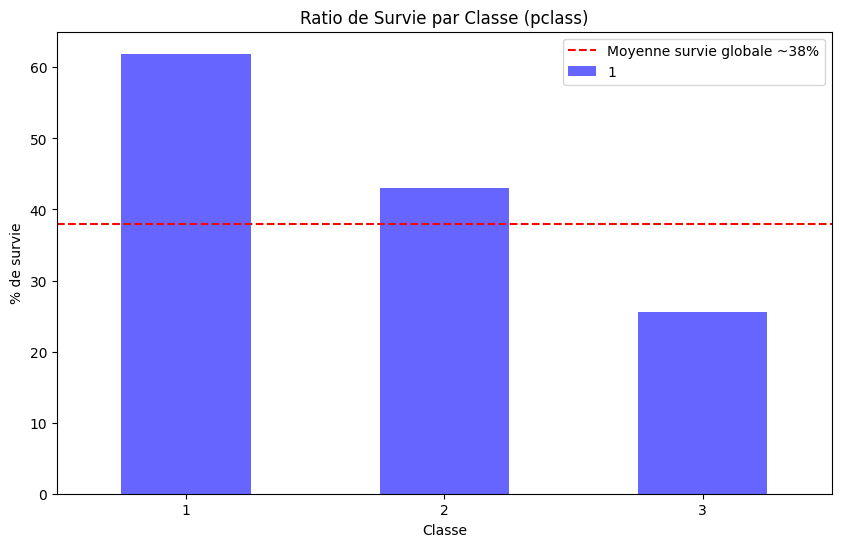

In [12]:
def plot_survival_by_class(df):
    """Affiche le tableau croisé et le graphique du taux de survie par classe."""
    # Tableau croisé : Classe vs Survie
    table = pd.crosstab(df['pclass'], df['survived'])
    print(table)

    # Tableau en pourcentage
    table_pourcent = pd.crosstab(df['pclass'], df['survived'], normalize='index') * 100
    print(table_pourcent)

    # Graphique
    table_pourcent[1].plot.bar(figsize=(10, 6), color='blue', alpha=0.6, rot=0)
    plt.axhline(y=38, color='red', linestyle='--', label='Moyenne survie globale ~38%')

    plt.title("Ratio de Survie par Classe (pclass)")
    plt.xlabel("Classe")
    plt.ylabel("% de survie")
    plt.legend()
    plt.show()


plot_survival_by_class(df_data)

Le lien entre classe et survie est **très marqué** :
- **1ère classe** : environ 63% de survivants — accès prioritaire aux canots de sauvetage.
- **2ème classe** : environ 47% de survivants.
- **3ème classe** : seulement environ 24% de survivants — situés dans les parties basses du navire, avec un accès limité aux sorties.

La classe sociale constitue donc l'un des facteurs les plus déterminants dans la survie, ce que confirmait déjà la matrice de corrélation.

---
---

#  Réflexion originale

> Les analyses qui suivent vont au-delà de l'analyse classique vue en cours. Elles visent à approfondir la compréhension des facteurs de survie à travers des questionnements supplémentaires et la création de nouvelles variables (*feature engineering*).

---

## 13. Survie selon le sexe <a id='section-13'></a>

**Questionnement :** Le protocole d'évacuation du Titanic a-t-il réellement favorisé les femmes ? La règle "femmes et enfants d'abord" est souvent citée, mais les données le confirment-elles concrètement ?

On analyse ici la variable `sex` directement, pour mesurer l'écart de survie entre hommes et femmes.

survived     0     1
sex                 
female    27.3  72.7
male      80.9  19.1


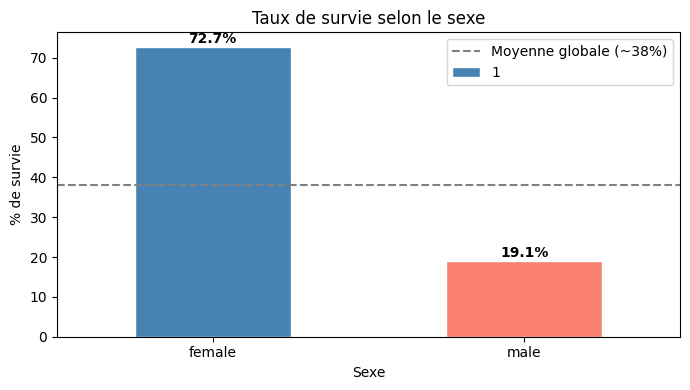

In [13]:
def plot_survival_by_sex(df):
    """Affiche le taux de survie selon le sexe avec un graphique en barres."""
    sex_survival = pd.crosstab(df['sex'], df['survived'], normalize='index') * 100
    print(sex_survival.round(1))

    fig, ax = plt.subplots(figsize=(7, 4))
    sex_survival[1].plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='white', ax=ax, rot=0)
    ax.axhline(y=38, color='gray', linestyle='--', label='Moyenne globale (~38%)')
    ax.set_title('Taux de survie selon le sexe')
    ax.set_xlabel('Sexe')
    ax.set_ylabel('% de survie')
    ax.legend()

    # Afficher les valeurs sur les barres
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                    ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_survival_by_sex(df_data)

Le résultat est sans appel : **les femmes ont survécu à environ 73%** contre seulement **~19% pour les hommes**. C'est l'écart le plus fort observé jusqu'ici — plus marqué encore que la classe ou le titre social. Cela confirme que le protocole d'évacuation a bel et bien été appliqué. Le sexe sera donc **la variable la plus discriminante** dans notre futur modèle de classification.

---
## 14. ⚙️ Feature Engineering : nouvelles variables <a id='section-14'></a>

**Questionnement :** Les variables disponibles dans le dataset suffisent-elles à capturer toute l'information pertinente ? Peut-on construire de nouvelles variables plus expressives à partir des données existantes ?

On crée ici quatre nouvelles variables :

| Variable | Calcul | Intérêt |
|---|---|---|
| `FamilySize` | `sibsp + parch + 1` | Taille totale du groupe familial |
| `IsAlone` | `FamilySize == 1` | Passager voyageant seul ou non |
| `HasCabin` | `cabin` non-nul → 1, sinon 0 | Indicateur de cabine connue (proxy de classe) |
| `AgeBand` | Découpage de `age` en tranches | Analyse par groupe d'âge |

 Nouvelles variables créées : FamilySize, IsAlone, HasCabin, AgeBand


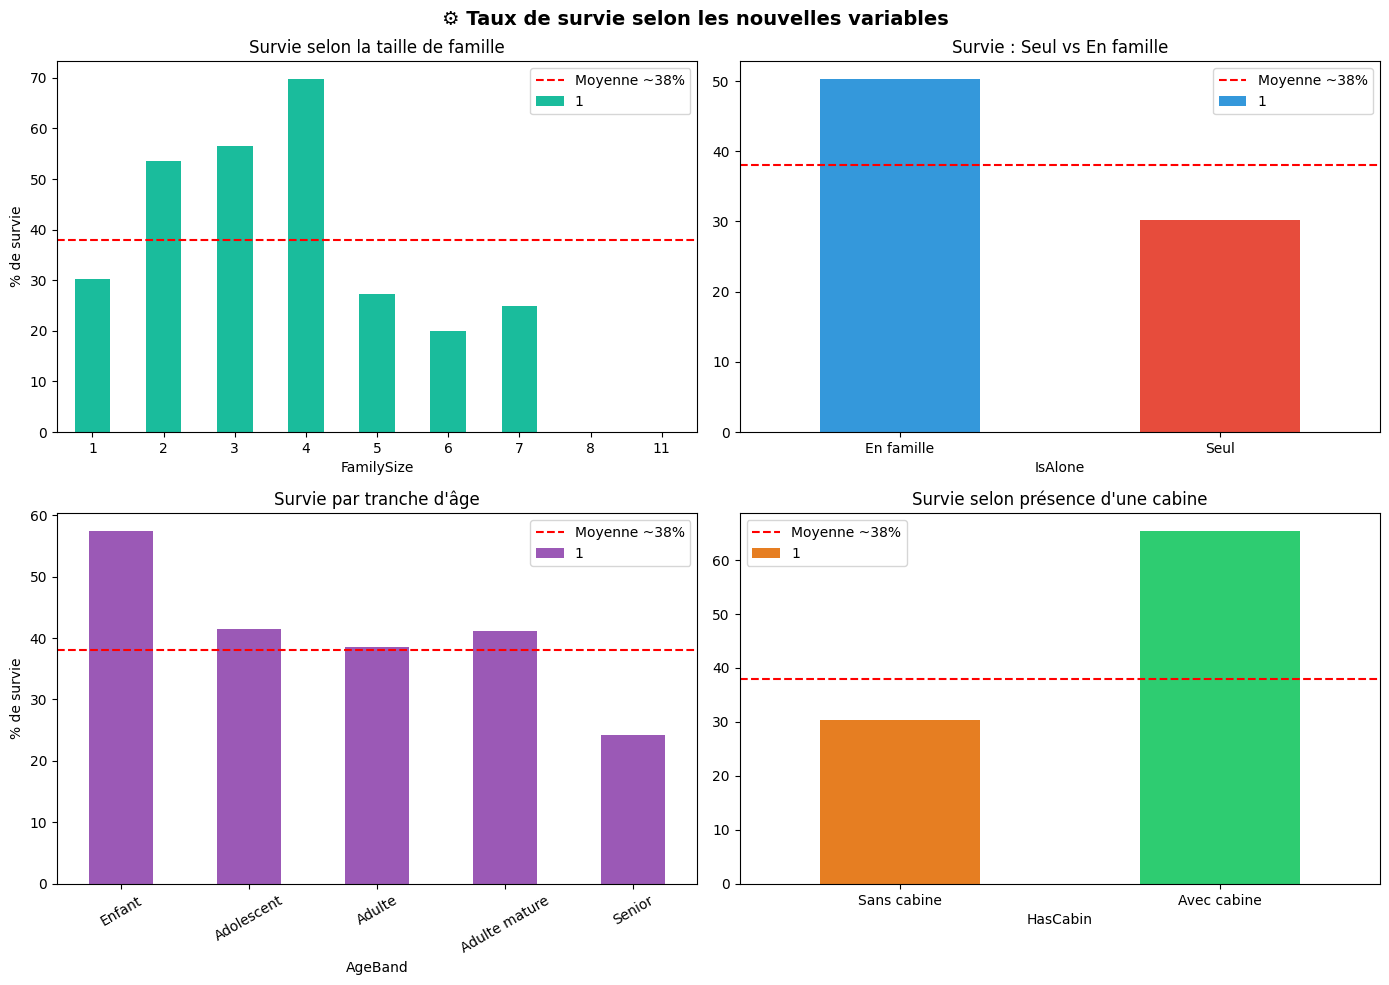

In [14]:
def create_new_features(df):
    """Crée de nouvelles variables à partir des colonnes existantes et retourne le dataframe enrichi."""
    df = df.copy()

    # Taille de la famille (passager inclus)
    df['FamilySize'] = df['sibsp'] + df['parch'] + 1

    # Indicateur : passager seul
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Indicateur : cabine connue
    df['HasCabin'] = df['cabin'].notnull().astype(int)

    # Tranche d'âge
    df['AgeBand'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                           labels=['Enfant', 'Adolescent', 'Adulte', 'Adulte mature', 'Senior'])

    print(" Nouvelles variables créées : FamilySize, IsAlone, HasCabin, AgeBand")
    return df


df_fe = create_new_features(df_data)


def plot_new_features_survival(df):
    """Visualise le taux de survie pour chaque nouvelle variable créée."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # FamilySize
    surv_family = pd.crosstab(df['FamilySize'], df['survived'], normalize='index') * 100
    surv_family[1].plot(kind='bar', ax=axes[0, 0], color='#1abc9c', rot=0)
    axes[0, 0].axhline(y=38, color='red', linestyle='--', label='Moyenne ~38%')
    axes[0, 0].set_title('Survie selon la taille de famille')
    axes[0, 0].set_ylabel('% de survie')
    axes[0, 0].legend()

    # IsAlone
    surv_alone = pd.crosstab(df['IsAlone'], df['survived'], normalize='index') * 100
    surv_alone[1].plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e74c3c'], rot=0)
    axes[0, 1].axhline(y=38, color='red', linestyle='--', label='Moyenne ~38%')
    axes[0, 1].set_title('Survie : Seul vs En famille')
    axes[0, 1].set_xticklabels(['En famille', 'Seul'], rotation=0)
    axes[0, 1].legend()

    # AgeBand
    surv_age = pd.crosstab(df['AgeBand'], df['survived'], normalize='index') * 100
    surv_age[1].plot(kind='bar', ax=axes[1, 0], color='#9b59b6', rot=30)
    axes[1, 0].axhline(y=38, color='red', linestyle='--', label='Moyenne ~38%')
    axes[1, 0].set_title("Survie par tranche d'âge")
    axes[1, 0].set_ylabel('% de survie')
    axes[1, 0].legend()

    # HasCabin
    surv_cabin = pd.crosstab(df['HasCabin'], df['survived'], normalize='index') * 100
    surv_cabin[1].plot(kind='bar', ax=axes[1, 1], color=['#e67e22', '#2ecc71'], rot=0)
    axes[1, 1].axhline(y=38, color='red', linestyle='--', label='Moyenne ~38%')
    axes[1, 1].set_title("Survie selon présence d'une cabine")
    axes[1, 1].set_xticklabels(['Sans cabine', 'Avec cabine'], rotation=0)
    axes[1, 1].legend()

    plt.suptitle('⚙️ Taux de survie selon les nouvelles variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_new_features_survival(df_fe)

Ces nouvelles variables révèlent des tendances intéressantes :
- **`FamilySize`** : les passagers seuls ou dans de très grandes familles (6+) survivent moins bien que ceux en petits groupes (2 à 4). Les familles de taille modérée semblent mieux s'en sortir.
- **`IsAlone`** : voyager seul est associé à un taux de survie plus faible — probablement car les familles s'entraidaient pour accéder aux canots.
- **`AgeBand`** : les **enfants** ont survécu à un taux plus élevé, ce qui confirme la règle d'évacuation. Les seniors ont le taux le plus faible.
- **`HasCabin`** : avoir une cabine enregistrée (souvent synonyme de 1ère classe) est fortement associé à la survie.

Ces variables enrichissent le dataset et pourront améliorer les performances du modèle de classification.